<a href="https://colab.research.google.com/github/Saroj-lab/Assessment1/blob/main/mini_project_perfected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/content/golden data.csv")
df.head()

,student_id,is_male,age_group,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,is_passing,final_grade
0,1,0,21-23,4.35,3.63,5.26,2.73,57.209999,10,57,0.000000,1,B
1,2,1,18-20,6.14,6.58,1.73,1.51,91.269997,10,49,60.599998,1,D
2,3,0,27-29,4.98,3.26,4.71,3.63,63.139999,2,38,0.000000,1,B
3,4,0,27-29,3.19,4.58,2.52,3.95,40.509998,6,50,0.000000,1,C
4,5,1,24-26,7.67,6.21,5.65,1.59,45.529999,6,41,72.699997,1,A


In [4]:
df.shape

(19222, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19222 entries, 0 to 19221
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             19222 non-null  int64  
 1   is_male                19222 non-null  int64  
 2   age_group              19222 non-null  object 
 3   study_hours_per_day    19222 non-null  float64
 4   sleep_hours            19222 non-null  float64
 5   gaming_hours           19222 non-null  float64
 6   social_media_hours     19222 non-null  float64
 7   attendance_percentage  19222 non-null  float64
 8   stress_level           19222 non-null  int64  
 9   focus_score            19222 non-null  int64  
 10  Previous_Grades        19222 non-null  float64
 11  is_passing             19222 non-null  int64  
 12  final_grade            19222 non-null  object 
dtypes: float64(6), int64(5), object(2)
memory usage: 1.9+ MB


In [6]:
df.describe()

,student_id,is_male,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,is_passing
count,19222.000000,19222.000000,19222.000000,19222.000000,19222.000000,19222.000000,19222.000000,19222.000000,19222.000000,19222.000000,19222.000000
mean,10000.801894,0.498491,5.252453,6.523534,2.986525,4.007754,69.964991,5.477474,64.431381,32.756862,0.839923
std,5774.605741,0.500011,2.741496,2.027727,1.734225,2.303758,17.408129,2.867246,20.181772,34.514856,0.366687
min,1.000000,0.000000,0.500000,3.000000,0.000000,0.000000,40.000000,1.000000,30.000000,0.000000,0.000000
25%,5001.250000,0.000000,2.900000,4.780000,1.490000,2.020000,54.820000,3.000000,47.000000,0.000000,1.000000
50%,10000.500000,0.000000,5.250000,6.510000,2.970000,4.020000,69.954998,5.000000,65.000000,26.100000,1.000000
75%,14996.750000,1.000000,7.630000,8.310000,4.490000,5.970000,85.070000,8.000000,82.000000,65.199997,1.000000
max,20000.000000,1.000000,10.000000,10.000000,6.000000,8.000000,100.000000,10.000000,99.000000,200.000000,1.000000


In [7]:
# 1. Function to extract the midpoint of range strings (e.g., '18-20' -> 19.0)
def get_range_midpoint(val):
    if pd.isna(val):
        return np.nan
    try:
        low, high = map(float, str(val).split("-"))
        return (low + high) / 2
    except ValueError:
        return np.nan


# 2. Convert string ranges to numeric midpoints
df["age"] = df["age_group"].apply(get_range_midpoint)

# 3. Replace missing values with the mean of the numeric age column
df["age"] = df["age"].fillna(df["age"].mean())


In [8]:
df.head()

,student_id,is_male,age_group,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,is_passing,final_grade,age
0,1,0,21-23,4.35,3.63,5.26,2.73,57.209999,10,57,0.000000,1,B,22.0
1,2,1,18-20,6.14,6.58,1.73,1.51,91.269997,10,49,60.599998,1,D,19.0
2,3,0,27-29,4.98,3.26,4.71,3.63,63.139999,2,38,0.000000,1,B,28.0
3,4,0,27-29,3.19,4.58,2.52,3.95,40.509998,6,50,0.000000,1,C,28.0
4,5,1,24-26,7.67,6.21,5.65,1.59,45.529999,6,41,72.699997,1,A,25.0


In [9]:
df = df.drop(columns=["age_group"])

In [10]:
df.head()

,student_id,is_male,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,is_passing,final_grade,age
0,1,0,4.35,3.63,5.26,2.73,57.209999,10,57,0.000000,1,B,22.0
1,2,1,6.14,6.58,1.73,1.51,91.269997,10,49,60.599998,1,D,19.0
2,3,0,4.98,3.26,4.71,3.63,63.139999,2,38,0.000000,1,B,28.0
3,4,0,3.19,4.58,2.52,3.95,40.509998,6,50,0.000000,1,C,28.0
4,5,1,7.67,6.21,5.65,1.59,45.529999,6,41,72.699997,1,A,25.0


In [11]:
df.head()


,student_id,is_male,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,is_passing,final_grade,age
0,1,0,4.35,3.63,5.26,2.73,57.209999,10,57,0.000000,1,B,22.0
1,2,1,6.14,6.58,1.73,1.51,91.269997,10,49,60.599998,1,D,19.0
2,3,0,4.98,3.26,4.71,3.63,63.139999,2,38,0.000000,1,B,28.0
3,4,0,3.19,4.58,2.52,3.95,40.509998,6,50,0.000000,1,C,28.0
4,5,1,7.67,6.21,5.65,1.59,45.529999,6,41,72.699997,1,A,25.0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

,0
student_id,0
is_male,0
study_hours_per_day,0
sleep_hours,0
gaming_hours,0
social_media_hours,0
attendance_percentage,0
stress_level,0
focus_score,0
Previous_Grades,0


In [15]:
df["is_male"].value_counts()

,count
is_male,
0,9640
1,9582


In [17]:
df["study_hours_per_day"].value_counts()

,count
study_hours_per_day,
9.58,36
5.25,35
5.23,35
9.10,35
1.64,34
...,...
2.46,10
6.29,10
5.88,10


In [18]:
df["sleep_hours"].value_counts()

,count
sleep_hours,
6.73,49
9.44,46
9.26,45
5.57,43
6.33,43
...,...
5.61,15
3.67,15
3.20,13


In [19]:
df["gaming_hours"].value_counts()

,count
gaming_hours,
2.58,49
0.93,47
2.19,47
5.65,47
0.61,46
...,...
3.47,19
2.24,18
4.77,17


In [20]:
df["social_media_hours"].value_counts()

,count
social_media_hours,
6.63,41
3.21,40
3.45,40
3.33,39
4.48,39
...,...
7.17,13
4.45,13
2.19,12


In [21]:
df["stress_level"].value_counts()

,count
stress_level,
2,1987
8,1981
3,1963
9,1939
6,1928
5,1924
1,1916
7,1900
4,1853


In [23]:
df["focus_score"].value_counts()

,count
focus_score,
87,299
69,297
51,297
33,295
83,295
...,...
60,250
71,248
34,248


In [25]:
df["Previous_Grades"].value_counts()

,count
Previous_Grades,
0.000000,9568
65.199997,539
68.599998,37
61.500000,35
65.099998,33
...,...
29.600000,1
113.900002,1
105.199997,1


In [27]:
df["final_grade"].value_counts()

,count
final_grade,
D,6421
A,3278
C,3233
B,3213
F,3077


In [28]:
df["age"].value_counts()

,count
age,
22.0,4463
25.0,4432
19.0,4399
28.0,4395
16.0,1533


focus_Score is numerical since the number corresponds to a quantity.
Stress level is ordinal since it rates the stress of a student in the range 1-10.
Age can be treated as numerical, instead of ordinal.

In [29]:
pd.crosstab(df["final_grade"], df["is_passing"])

is_passing,0,1
final_grade,,
A,0,3278
B,0,3213
C,0,3233
D,0,6421
F,3077,0


Since, grades, A,B,C,D strictly correspond to is_passing=i, and F correspond to is_passing=0 , we can drop final_grade column.



In [30]:
df = df.drop(columns=["final_grade"])

In [33]:
df = df.drop(columns=["student_id"])

In [36]:
df.head()

,is_male,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,is_passing,age
0,0,4.35,3.63,5.26,2.73,57.209999,10,57,0.000000,1,22.0
1,1,6.14,6.58,1.73,1.51,91.269997,10,49,60.599998,1,19.0
2,0,4.98,3.26,4.71,3.63,63.139999,2,38,0.000000,1,28.0
3,0,3.19,4.58,2.52,3.95,40.509998,6,50,0.000000,1,28.0
4,1,7.67,6.21,5.65,1.59,45.529999,6,41,72.699997,1,25.0


In [34]:
df["attendance_percentage"].value_counts()

,count
attendance_percentage,
99.669998,11
40.509998,10
62.509998,10
84.500000,10
60.680000,10
...,...
59.330002,1
48.860001,1
57.820000,1


In [37]:
features_to_check = [
    "age",
    "study_hours_per_day",
    "sleep_hours",
    "gaming_hours",
    "social_media_hours",
    "attendance_percentage",
    "Previous_Grades",
    "focus_score",
]

features_to_check = [col for col in features_to_check if col in df.columns]

outlier_summary = {}

for col in features_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        "outlier_count": len(outliers),
        "percentage": round(len(outliers) / len(df) * 100, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
    }

outliers_df = pd.DataFrame(outlier_summary).T
print(outliers_df)

                       outlier_count  percentage  lower_bound  upper_bound
age                              0.0        0.00        10.00        34.00
study_hours_per_day              0.0        0.00        -4.19        14.73
sleep_hours                      0.0        0.00        -0.52        13.61
gaming_hours                     0.0        0.00        -3.01         8.99
social_media_hours               0.0        0.00        -3.90        11.89
attendance_percentage            0.0        0.00         9.44       130.44
Previous_Grades                 21.0        0.11       -97.80       163.00
focus_score                      0.0        0.00        -5.50       134.50


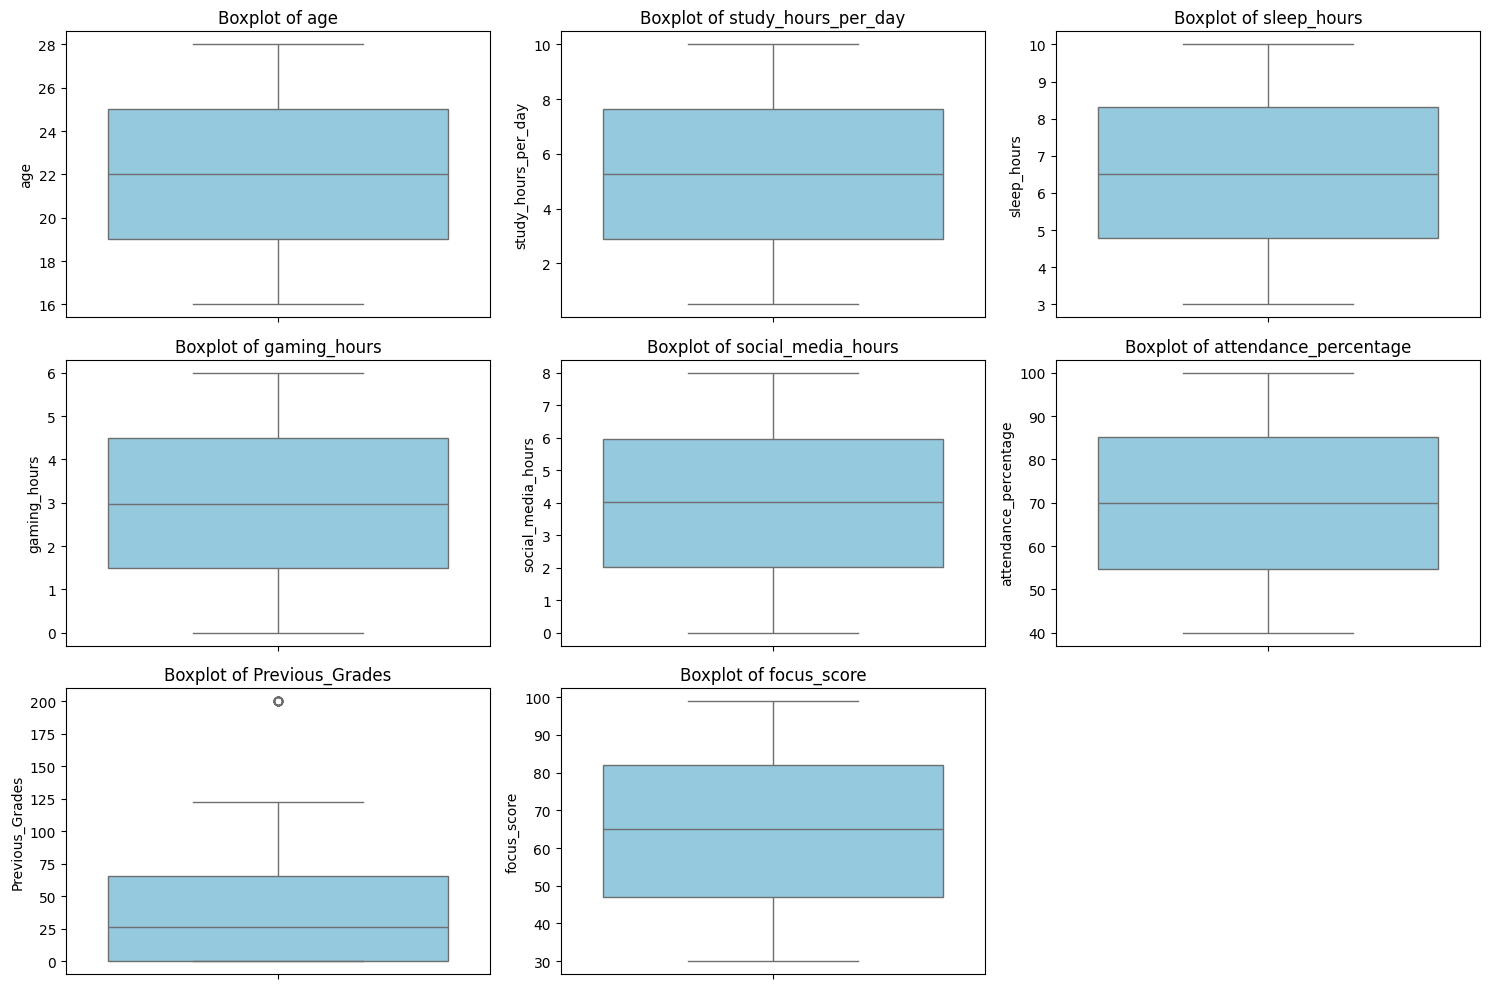

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, col in enumerate(features_to_check, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [40]:
for col in features_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = (df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))
    print(f"{col}: {outliers.sum()} outliers")

age: 0 outliers
study_hours_per_day: 0 outliers
sleep_hours: 0 outliers
gaming_hours: 0 outliers
social_media_hours: 0 outliers
attendance_percentage: 0 outliers
Previous_Grades: 21 outliers
focus_score: 0 outliers


we shall winzorise the Previous_Grades because it has 21 outliers.


In [41]:
Q1 = df["Previous_Grades"].quantile(0.25)
Q3 = df["Previous_Grades"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["Previous_Grades"] = df["Previous_Grades"].clip(
    lower=lower_bound, upper=upper_bound
)

In [42]:
df.head()

,is_male,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,is_passing,age
0,0,4.35,3.63,5.26,2.73,57.209999,10,57,0.000000,1,22.0
1,1,6.14,6.58,1.73,1.51,91.269997,10,49,60.599998,1,19.0
2,0,4.98,3.26,4.71,3.63,63.139999,2,38,0.000000,1,28.0
3,0,3.19,4.58,2.52,3.95,40.509998,6,50,0.000000,1,28.0
4,1,7.67,6.21,5.65,1.59,45.529999,6,41,72.699997,1,25.0


In [44]:
# Separate target variable from features
X = df.drop(columns=["is_passing"])
y = df["is_passing"]

In [45]:
#verification
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)
print("Feature columns:", list(X.columns))


Features shape (X): (19222, 10)
Target shape (y): (19222,)
Feature columns: ['is_male', 'study_hours_per_day', 'sleep_hours', 'gaming_hours', 'social_media_hours', 'attendance_percentage', 'stress_level', 'focus_score', 'Previous_Grades', 'age']


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15377, 10)
X_test shape: (3845, 10)
y_train shape: (15377,)
y_test shape: (3845,)


since the test score is already given in the range from 1-10, we do not need to do ordinal encoding on it.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = [
    col for col in X_train.columns if col not in ["is_male", "stress_level"]
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [48]:
X_train_scaled.head()

,is_male,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,age
16295,1,1.338368,1.118188,-1.701976,1.403908,-0.403655,10,0.624911,0.939222,0.551112
9265,1,1.112722,-1.704492,-0.910383,-1.279910,0.223538,8,-0.762757,0.671628,-0.237576
17322,0,-0.670606,0.091759,-0.286353,-1.510449,1.452055,1,0.624911,0.627998,-0.237576
3237,1,-1.045469,0.861581,0.395458,0.185967,-0.990606,6,1.566543,-0.948479,-0.237576
1699,1,-1.198326,-0.984018,0.730585,1.464805,-0.021935,10,0.525792,1.166095,-0.237576


In [50]:
#logistic regression, since the target column "is-passing" is binary.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8400520156046815

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       615
           1       0.84      1.00      0.91      3230

    accuracy                           0.84      3845
   macro avg       0.42      0.50      0.46      3845
weighted avg       0.71      0.84      0.77      3845


Confusion Matrix:
 [[   0  615]
 [   0 3230]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


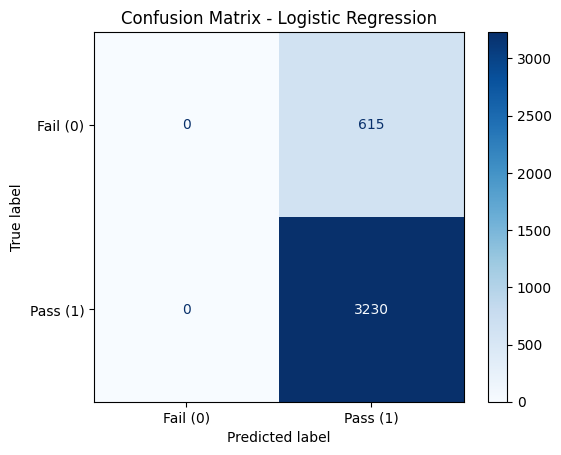

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Fail (0)", "Pass (1)"], cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.grid(False)
plt.show()

In [52]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

print(lr_metrics)

      Metric     Score
0   Accuracy  0.840052
1  Precision  0.840052
2     Recall  1.000000
3   F1-Score  0.913074


In [53]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Train Decision Tree Model (using unscaled X_train)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Make Predictions
dt_pred = dt_model.predict(X_test)

# 3. Record Metrics
dt_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, dt_pred),
        precision_score(y_test, dt_pred),
        recall_score(y_test, dt_pred),
        f1_score(y_test, dt_pred)
    ]
})

print("Decision Tree Performance:")
print(dt_metrics)

Decision Tree Performance:
      Metric     Score
0   Accuracy  0.709753
1  Precision  0.839871
2     Recall  0.808669
3   F1-Score  0.823975


Classification Report:
               precision    recall  f1-score   support

           0       0.16      0.19      0.17       615
           1       0.84      0.81      0.82      3230

    accuracy                           0.71      3845
   macro avg       0.50      0.50      0.50      3845
weighted avg       0.73      0.71      0.72      3845

Confusion Matrix:
 [[ 117  498]
 [ 618 2612]]


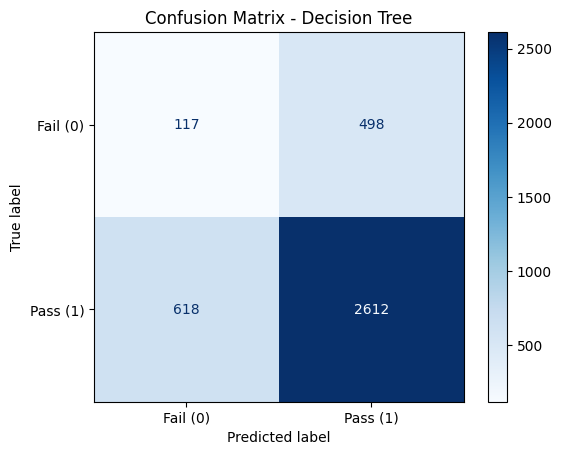


Feature Importances:
                  Feature  Importance
1    study_hours_per_day    0.146238
4     social_media_hours    0.146054
5  attendance_percentage    0.141544
2            sleep_hours    0.139661
3           gaming_hours    0.133856
7            focus_score    0.112905
8        Previous_Grades    0.079939
9                    age    0.046053
6           stress_level    0.040611
0                is_male    0.013139


In [54]:
#evaluating the decision tree
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("Classification Report:\n", classification_report(y_test, dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred, display_labels=["Fail (0)", "Pass (1)"], cmap="Blues"
)
plt.title("Confusion Matrix - Decision Tree")
plt.grid(False)
plt.show()

dt_feature_importance = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": dt_model.feature_importances_}
).sort_values(by="Importance", ascending=False)

print("\nFeature Importances:\n", dt_feature_importance)

In [55]:
#training random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       615
           1       0.84      1.00      0.91      3230

    accuracy                           0.84      3845
   macro avg       0.42      0.50      0.46      3845
weighted avg       0.71      0.84      0.77      3845

Confusion Matrix:
 [[   0  615]
 [   1 3229]]


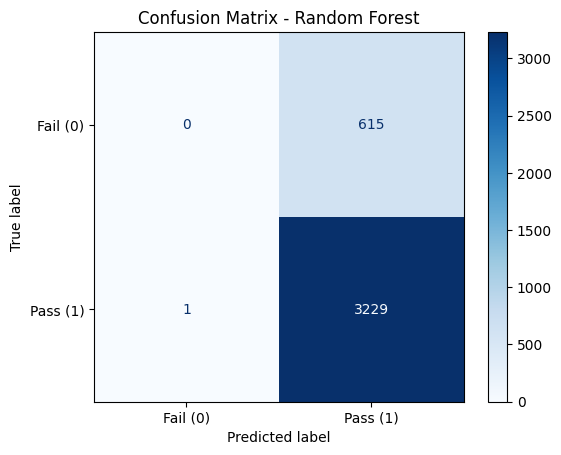

In [56]:
#evaluating random tree forest

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("Classification Report:\n", classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=["Fail (0)", "Pass (1)"], cmap="Blues"
)
plt.title("Confusion Matrix - Random Forest")
plt.grid(False)
plt.show()

KNN Performance:
      Metric     Score
0   Accuracy  0.811443
1  Precision  0.838972
2     Recall  0.959752
3   F1-Score  0.895307

Classification Report:
               precision    recall  f1-score   support

           0       0.13      0.03      0.05       615
           1       0.84      0.96      0.90      3230

    accuracy                           0.81      3845
   macro avg       0.49      0.50      0.47      3845
weighted avg       0.73      0.81      0.76      3845

Confusion Matrix:
 [[  20  595]
 [ 130 3100]]


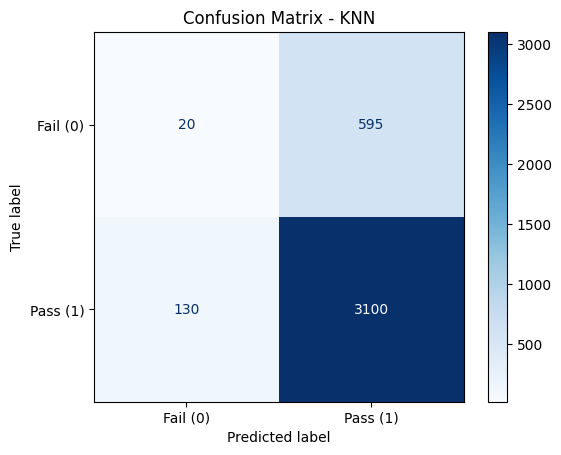

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, knn_pred),
        precision_score(y_test, knn_pred),
        recall_score(y_test, knn_pred),
        f1_score(y_test, knn_pred)
    ]
})

print("KNN Performance:")
print(knn_metrics)

print("\nClassification Report:\n", classification_report(y_test, knn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, knn_pred, display_labels=["Fail (0)", "Pass (1)"], cmap="Blues"
)
plt.title("Confusion Matrix - KNN")
plt.grid(False)
plt.show()

In [58]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, knn_pred),
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, knn_pred),
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, knn_pred),
    ],
}).sort_values(by="F1-Score", ascending=False)

print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.840052   0.840052 1.000000  0.913074
      Random Forest  0.839792   0.840010 0.999690  0.912921
K-Nearest Neighbors  0.811443   0.838972 0.959752  0.895307
      Decision Tree  0.709753   0.839871 0.808669  0.823975


In [59]:

best_f1_model = comparison_df.iloc[0]
print("Best Model based on F1-Score:")
print(best_f1_model)

Best Model based on F1-Score:
Model        Logistic Regression
Accuracy                0.840052
Precision               0.840052
Recall                       1.0
F1-Score                0.913074
Name: 0, dtype: object


In [60]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    StandardScaler(), LogisticRegression(random_state=42)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1"]
cv_results = cross_validate(
    pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False
)

print(f"Mean Accuracy:  {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
print(f"Mean Precision: {np.mean(cv_results['test_precision']):.4f} (+/- {np.std(cv_results['test_precision']):.4f})")
print(f"Mean Recall:    {np.mean(cv_results['test_recall']):.4f} (+/- {np.std(cv_results['test_recall']):.4f})")
print(f"Mean F1-Score:  {np.mean(cv_results['test_f1']):.4f} (+/- {np.std(cv_results['test_f1']):.4f})")

Mean Accuracy:  0.8399 (+/- 0.0001)
Mean Precision: 0.8399 (+/- 0.0001)
Mean Recall:    1.0000 (+/- 0.0000)
Mean F1-Score:  0.9130 (+/- 0.0001)


In [61]:
from sklearn.model_selection import GridSearchCV

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="liblinear", random_state=42),
)

param_grid = {
    "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    "logisticregression__penalty": ["l1", "l2"],
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Best Parameters: {'logisticregression__C': 0.01, 'logisticregression__penalty': 'l1'}
Best CV F1-Score: 0.9130


Tuned Model Test Performance:
Accuracy:  0.8401
Precision: 0.8401
Recall:    1.0000
F1-Score:  0.9131

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       615
           1       0.84      1.00      0.91      3230

    accuracy                           0.84      3845
   macro avg       0.42      0.50      0.46      3845
weighted avg       0.71      0.84      0.77      3845



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


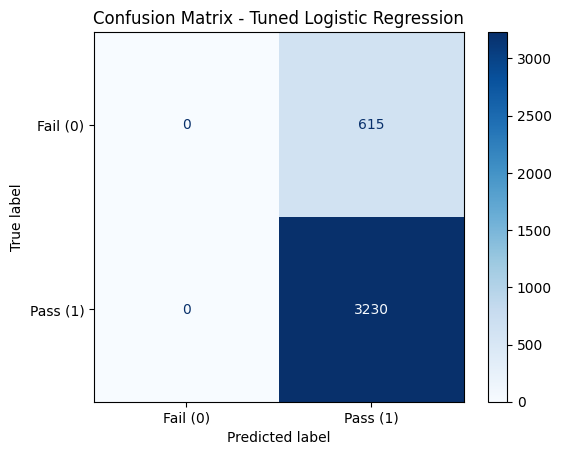

In [62]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("Tuned Model Test Performance:")
print(f"Accuracy:  {accuracy_score(y_test, best_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_pred):.4f}")
print(f"Recall:    {recall_score(y_test, best_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, best_pred):.4f}")

print("\nClassification Report:\n", classification_report(y_test, best_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, display_labels=["Fail (0)", "Pass (1)"], cmap="Blues"
)
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.grid(False)
plt.show()

In [63]:
import joblib

joblib.dump(best_model, "best_logistic_regression_model.pkl")
print("Model saved successfully as 'best_logistic_regression_model.pkl'")

Model saved successfully as 'best_logistic_regression_model.pkl'
